In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [ ]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [ ]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [ ]:
model = keras.Sequential(
  [
    layers.Input(shape=(4,)),
    layers.Dense(8, activation="sigmoid", name="layer1"),
    layers.Dense(6, activation="sigmoid", name="added_layer1"),
    layers.Dense(4, activation="sigmoid", name="added_layer2"),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ added_layer1 (Dense)            │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ added_layer2 (Dense)            │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y = model(X)
print(y[149])

tf.Tensor([0.393494  0.4200422 0.7308619], shape=(3,), dtype=float32)


In [ ]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2783  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2772 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2761 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2750 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2740 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2730
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2719 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2709 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2699 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2689 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2679 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2669 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2659 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2650 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2640 
Epoch 16/500
5/5 ━

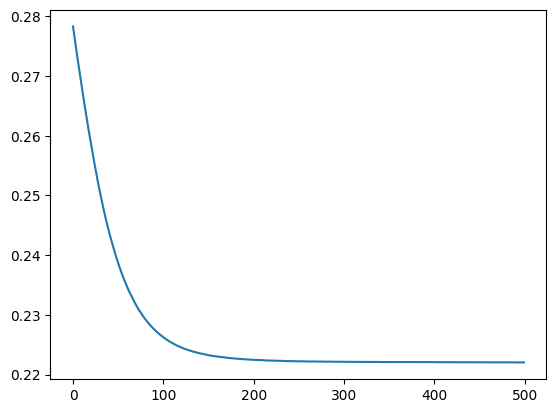

In [ ]:
plt.plot(history.history['loss'])
plt.show()

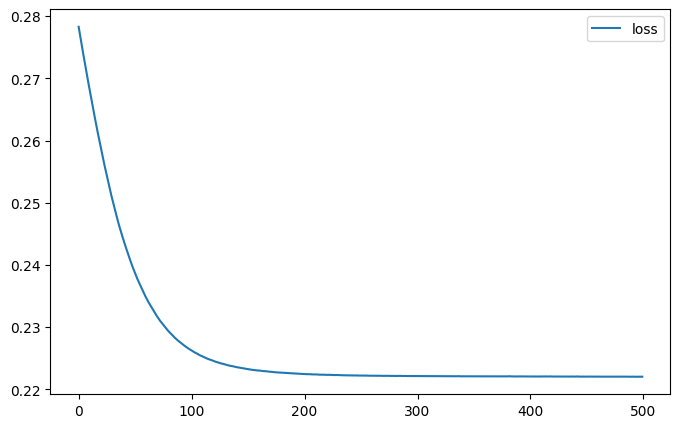

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [ ]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


array([[0.3345597 , 0.3335049 , 0.33465305]], dtype=float32)

```markdown
## Entrenamiento y Evaluación de la Nueva Red (Arquitectura con 2 Capas Adicionales)

Procedemos a compilar y entrenar la nueva red durante 500 épocas utilizando el mismo optimizador SGD y tasa de aprendizaje para poder comparar justamente la velocidad de convergencia y la pérdida final.
```

In [ ]:
import time

# Usamos la misma configuración
optimizer_new = tf.keras.optimizers.SGD(learning_rate=0.03)
loss_new = tf.keras.losses.MeanSquaredError()
model.compile(optimizer=optimizer_new, loss=loss_new, metrics=['accuracy'])

# Medimos el tiempo para evaluar la velocidad de entrenamiento
start_time = time.time()
history_new = model.fit(X, Y, epochs=500, verbose=0) # verbose=0 para no inundar el output
end_time = time.time()

print(f"Tiempo de entrenamiento (Nueva red con +2 capas): {end_time - start_time:.2f} segundos")
print(f"Pérdida (Loss) final: {history_new.history['loss'][-1]:.4f}")

Tiempo de entrenamiento (Nueva red con +2 capas): 29.34 segundos
Pérdida (Loss) final: 0.2217


```markdown
### Comparación Gráfica del Historial de Pérdida (Curva de Error)
Graficamos las pérdidas del modelo original (si mantienes el historial en memoria) o analizamos la curva actual.
```

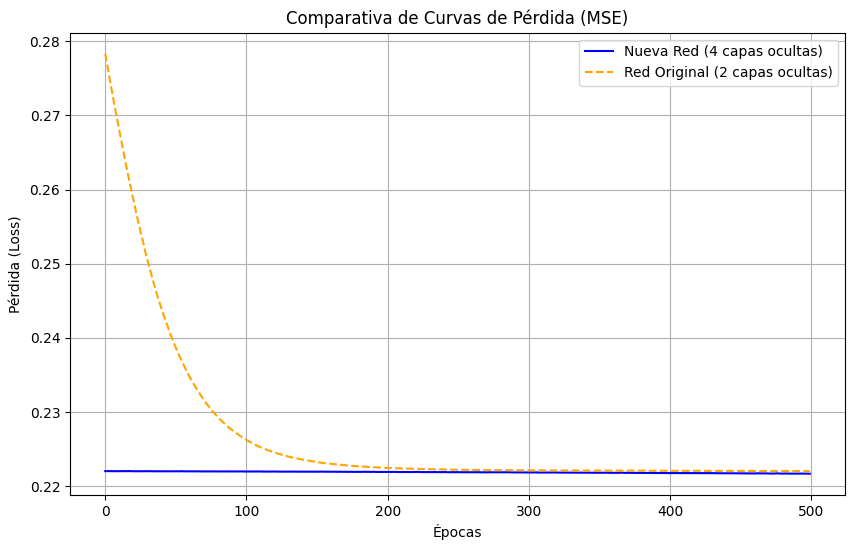

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_new.history['loss'], label='Nueva Red (4 capas ocultas)', color='blue')
if 'history' in globals():
    plt.plot(history.history['loss'], label='Red Original (2 capas ocultas)', color='orange', linestyle='--')
plt.title('Comparativa de Curvas de Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)
plt.show()

```markdown
### Evaluación de Calidad de Clasificación

Probamos las predicciones del modelo con una entrada de prueba, al igual que en la red original, para observar cómo cambian las probabilidades asignadas.
```

In [ ]:
# Comparación de predicción para la entrada de prueba
test_input = np.array([[3,3,1,1]])
pred = model.predict(test_input)
print(f"Predicción de la nueva red para [3, 3, 1, 1]:\n{pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicción de la nueva red para [3, 3, 1, 1]:
[[0.33513042 0.33481136 0.33255166]]
